<a href="https://colab.research.google.com/github/sramalhao/shark_attacks/blob/main/shark_attacks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Shark Attack File Analysis


In this project, we explore the `attacks.csv` dataset. The original data is quite raw and requires Data Cleaning and Natural Language Processing (NLP) techniques so we can extract annual trends, the most dangerous locations, common injuries, and the most frequent shark species.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style="whitegrid")


In [ ]:
# Loading the dataset
# 'latin-1' encoding is recommended as there are many special characters in the reports

data = pd.read_csv('/content/attacks.csv', encoding='latin-1')


In [ ]:
# Initial cleaning: Remove trailing/leading whitespaces from column names
data.columns = data.columns.str.strip()

display(data.head(3))

,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,...,Fatal (Y/N),Time,Species,Investigator or Source,pdf,href formula,href,Case Number.1,Case Number.2,original order
0,2017.06.11,2017-06-11,2017.0,Unprovoked,AUSTRALIA,Western Australia,"Point Casuarina, Bunbury",Body boarding,Paul Goff,M,...,N,08h30,"White shark, 4 m","WA Today, 6/11/2017",2017.06.11-Goff.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2017.06.11,2017.06.11,6095.0
1,2017.06.10.b,2017-06-10,2017.0,Unprovoked,AUSTRALIA,Victoria,"Flinders, Mornington Penisula",Surfing,female,F,...,N,15h45,7 gill shark,NaN,2017.06.10.b-Flinders.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2017.06.10.b,2017.06.10.b,6094.0
2,2017.06.10.a,2017-06-10,2017.0,Unprovoked,USA,Florida,"Ponce Inlet, Volusia County",Surfing,Bryan Brock,M,...,N,10h00,NaN,"Daytona Beach News-Journal, 6/10/2017",2017.06.10.a-Brock.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2017.06.10.a,2017.06.10.a,6093.0


## 1. Historical Trend (Annual attacks since 1900)


To understand how the frequency of shark attacks has changed over time, the Year column was converted to numeric values (coercing any invalid formats), and the dataset was filtered to only include incidents that occurred after the year 1900.

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

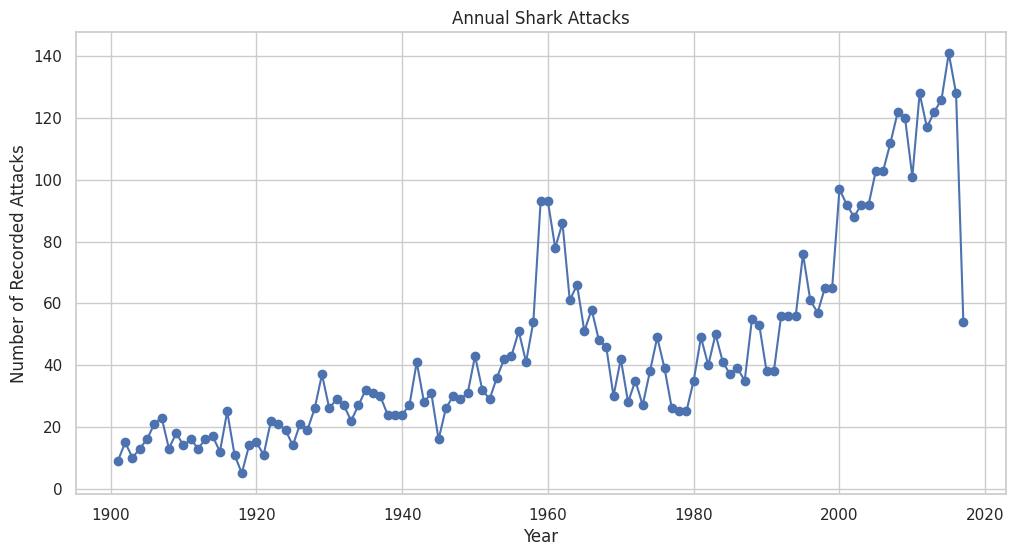

In [ ]:
data['Year'] = pd.to_numeric(data['Year'], errors='coerce')

data_years = data[data['Year'] > 1900]
attacks_per_year = data_years.groupby('Year').size()

plt.figure(figsize=(12, 6))
attacks_per_year.plot(kind='line', marker='o')
plt.title('Annual Shark Attacks')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Recorded Attacks', fontsize=12)
plt.show()



## 2. Most Dangerous Countries, Areas, and Locations



In [ ]:
attacks_country = data_years.groupby('Country').size().sort_values(ascending=False)

for country in attacks_country.head(5).index:
    print(f"📍 BREAKDOWN: {country}")
    display(data['Area'].value_counts().head(3))


📍 BREAKDOWN: USA


,count
Area,
Florida,1015
New South Wales,476
Queensland,307


📍 BREAKDOWN: AUSTRALIA


,count
Area,
Florida,1015
New South Wales,476
Queensland,307


📍 BREAKDOWN: SOUTH AFRICA


,count
Area,
Florida,1015
New South Wales,476
Queensland,307


📍 BREAKDOWN: PAPUA NEW GUINEA


,count
Area,
Florida,1015
New South Wales,476
Queensland,307


📍 BREAKDOWN: BRAZIL


,count
Area,
Florida,1015
New South Wales,476
Queensland,307


## 3. Most Frequently Injured Body Parts (Text Analysis)


In [ ]:
data['Injury'].unique()

array(['No injury, board bitten', 'No injury, knocke off board',
       'Laceration to left foot', ..., 'FATAL, leg stripped of flesh  ',
       'FATAL, knocked overboard by tail of shark & carried off by shark ',
       'FATAL. "Shark bit him in half, carrying away the lower extremities" '],
      dtype=object)

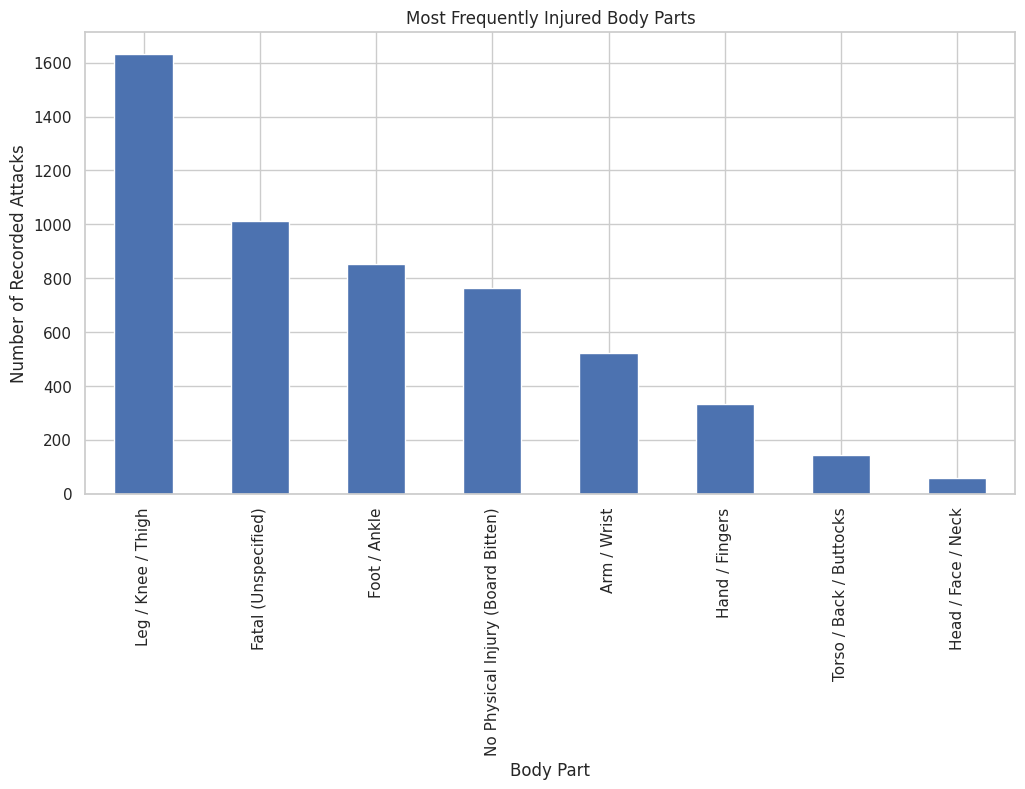

In [ ]:
data['Injury'].unique()

def extraction_body_parts(text):
  if pd.isna(text):
        return 'Unknown'
  text = str(text).lower()

  if re.search(r'leg|calf|thigh|knee', text):
      return 'Leg / Knee / Thigh'
  elif re.search(r'foot|feet|toe|ankle|heel', text):
      return 'Foot / Ankle'
  elif re.search(r'arm|wrist|forearm|bicep|elbow', text):
      return 'Arm / Wrist'
  elif re.search(r'hand|finger', text):
      return 'Hand / Fingers'
  elif re.search(r'torso|chest|abdomen|stomach|back|buttock', text):
      return 'Torso / Back / Buttocks'
  elif re.search(r'head|face|neck', text):
      return 'Head / Face / Neck'
  elif re.search(r'fatal|drowned', text):
      return 'Fatal (Unspecified)'
  elif re.search(r'no injury|board', text):
      return 'No Physical Injury (Board Bitten)'
  else:
      return 'Other'
data['Injuried_Body_Part'] = data['Injury'].apply(extraction_body_parts)

body_parts = data[~data['Injuried_Body_Part'].isin(['Unknown', 'Other'])].groupby('Injuried_Body_Part').size().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
body_parts.plot(kind='bar')
plt.title('Most Frequently Injured Body Parts')
plt.xlabel('Body Part', fontsize=12)
plt.ylabel('Number of Recorded Attacks', fontsize=12)
plt.show()



## 4. Most Common Times of Day (Time Conversion)


In [ ]:
data['Time'].unique()

array(['08h30', '15h45', '10h00', nan, 'Shortly before 12h00', 'Morning',
       '17h00', '14h30', '17h34', '17h10', '11h00', '11h15', '14h00',
       '16h00', '08h50', 'Afternoon', '09h00', '13h30', '13h45', '17h45',
       '13h00', '15h00', '18h30', '09h30', '10h20', '12h00', '07h30',
       '12h30', '18h00', '07h00', '02h00', '10h30', '09h50', '11h30',
       '17h30', '9h00', '10h43', 'After noon', '15h15', '15h40',
       'Late afternoon', '16h30', '19h05', '1300', '14h30 / 15h30',
       '22h00', '16h20', '14h34', '15h25', '14h55', '06h00', '17h46',
       'Morning ', '13h20', '15h49', '08h00', '10h45', '19h00',
       'Midnight', '09h30 / 10h00', '10h15', '18h15', '04h00', '14h50',
       '13h50', '19h20', '10h25', '16h50', '10h45-11h15', '16h45',
       '15h52', '06h15', '14h40', '19h45', '15h30', '10h10', '08h45',
       'Evening', '12h10', '18h05', '19h30', '11h41', '12h25', '17h51',
       '16h12', '12h45', '10h50', '14h15', '09h45', '11h45', '06h45',
       '05h00', '03h30',

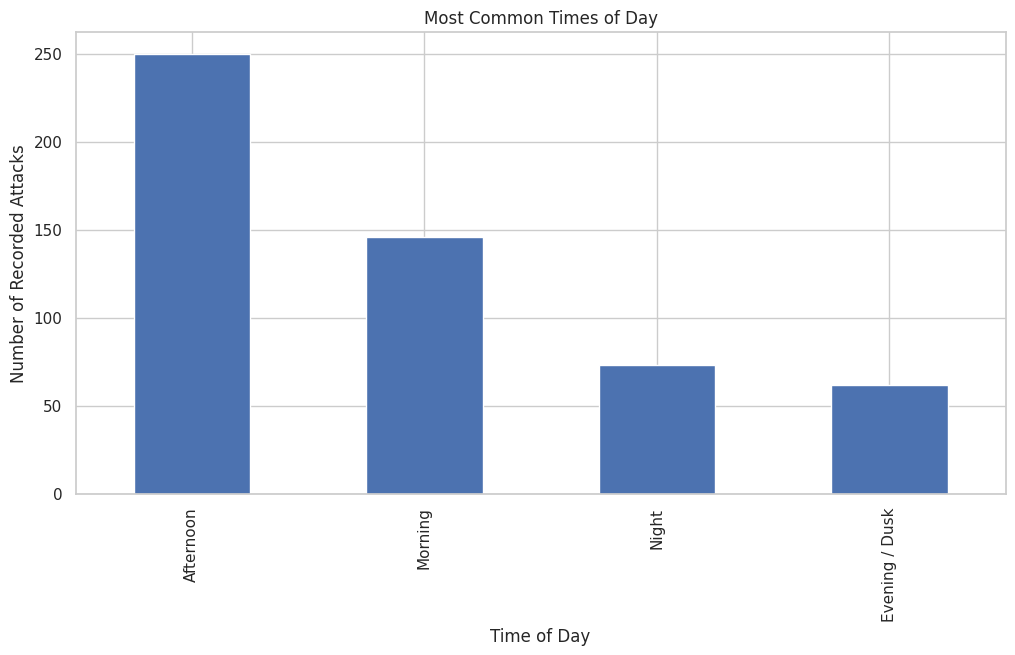

In [ ]:
def clean_time(time_text):
  if pd.isna(time_text):
    return 'Unknown'

  text = str(time_text).lower()

  match_hour = re.search(r'\d{1,2}:\d{2}', text)

  if match_hour:
    hour = int(match_hour.group().split(':')[1])
    if 5 <= hour <= 12:
      return 'Morning'
    if 12 <= hour < 17:
      return 'Afternoon'
    if 17 <= hour < 21:
      return 'Evening / Dusk'
    else:
      return 'Night'

  if any(word in text for word in ['morning', 'dawn', 'a.m.', 'am']):
      return 'Morning'
  if any(word in text for word in ['afternoon', 'midday', 'noon', 'p.m.', 'pm']):
      return 'Afternoon'
  if any(word in text for word in ['evening', 'dusk', 'sunset', 'late afternoon']):
      return 'Evening / Dusk'
  if any(word in text for word in ['night', 'dark', 'midnight']):
      return 'Night'

  return 'Unknown'

data['Time_of_Day'] = data['Time'].apply(clean_time)

periods = data[data['Time_of_Day'] != 'Unknown'].groupby('Time_of_Day').size().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
periods.plot(kind='bar')
plt.title('Most Common Times of Day')
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Number of Recorded Attacks', fontsize=12)
plt.show()


## 5. Most Involved Shark Species


In [ ]:
data['Species'].unique()

array(['White shark, 4 m', '7 gill shark', nan, ..., 'Blue pointers',
       'Said to involve a grey nurse shark that leapt out of the water and  seized the boy but species identification is questionable',
       'N'], dtype=object)

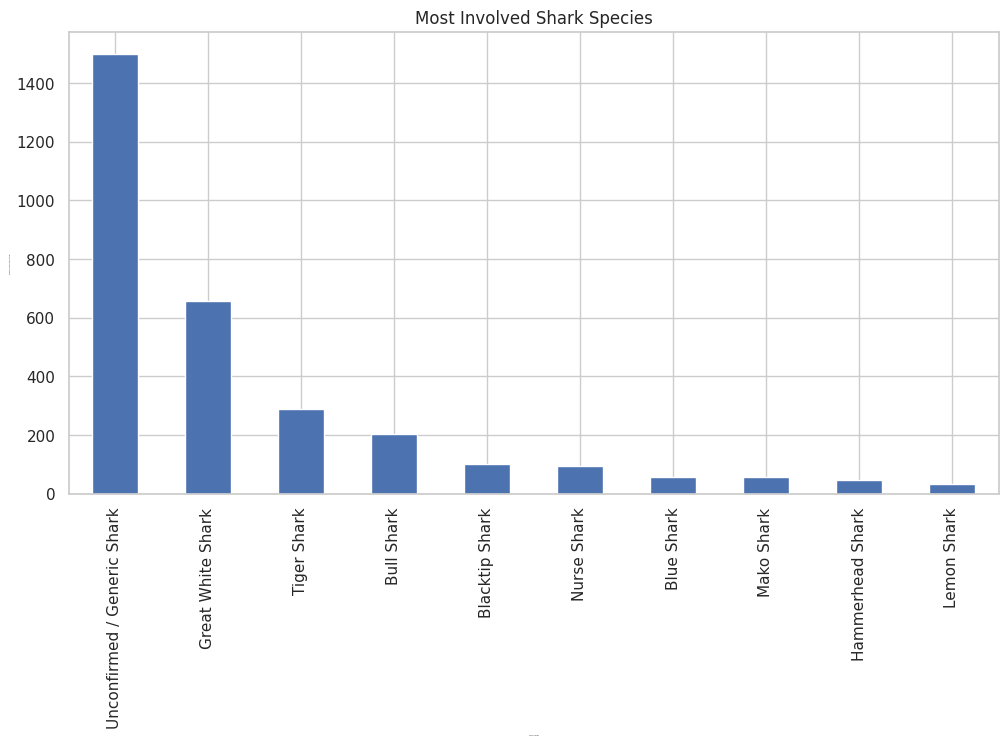

In [ ]:
def extract_species(species_text):
  if pd.isna(species_text):
    return 'Unknown'

  text = str(species_text).lower()

  if re.search(r'white|great white', text):
    return 'Great White Shark'
  elif re.search(r'tiger', text):
    return 'Tiger Shark'
  elif re.search(r'bull|zambesi', text): # Zambesi is the local name for Bull Shark in South Africa
    return 'Bull Shark'
  elif re.search(r'nurse', text):
    return 'Nurse Shark'
  elif re.search(r'hammerhead', text):
    return 'Hammerhead Shark'
  elif re.search(r'mako', text):
    return 'Mako Shark'
  elif re.search(r'blacktip', text):
    return 'Blacktip Shark'
  elif re.search(r'blue', text):
    return 'Blue Shark'
  elif re.search(r'lemon', text):
    return 'Lemon Shark'
  elif 'shark' in text:
    return 'Unconfirmed / Generic Shark'
  else:
    return 'Unknown'

  return 'Unknown'

data['Clean_Species'] = data['Species'].apply(extract_species)

identified_species = data[~data['Clean_Species'].isin(['Unconfirmed / Generic Shark', 'Unknown'])].groupby('Clean_Species').size().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
attacks_by_species.plot(kind='bar')
plt.title('Most Involved Shark Species')
plt.xlabel('Shark Species', fontsize=1)
plt.ylabel('Number of Recorded Attacks', fontsize=1)
plt.show()


## 6. High-Risk Activities (What were the victims doing?)


In [ ]:
data['Activity'].unique()

array(['Body boarding', 'Surfing', 'Surfing ', ...,
       'Crew swimming alongside their anchored ship',
       '4 men were bathing', 'Wreck of  large double sailing canoe'],
      dtype=object)

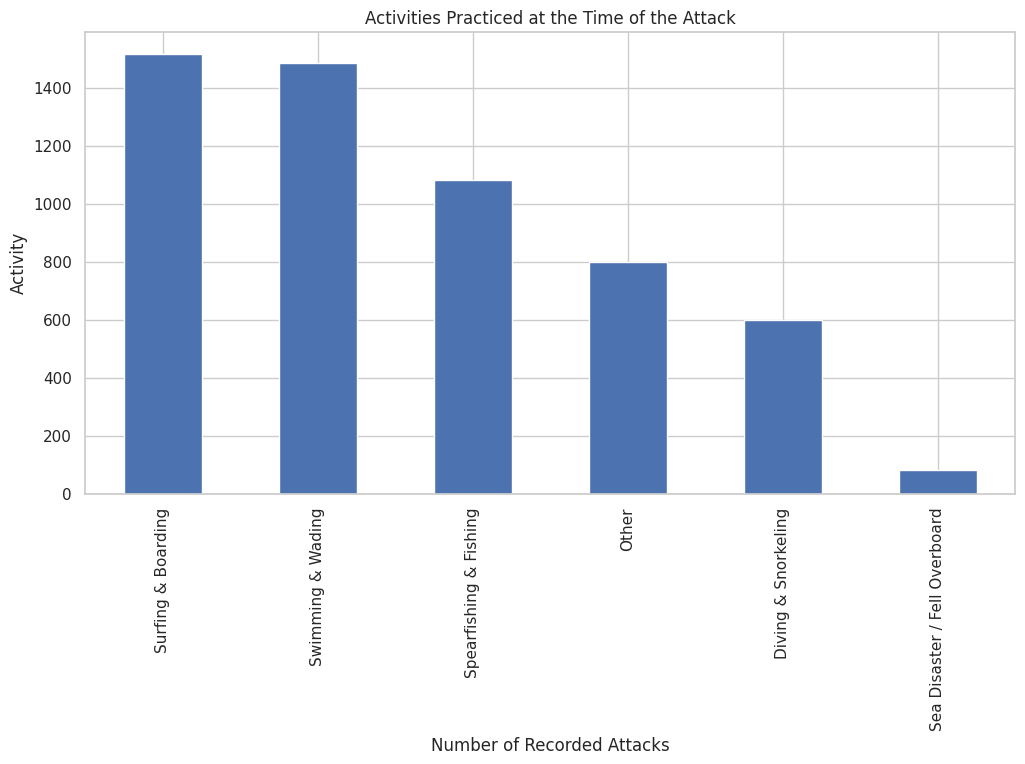

In [ ]:
from os import W_OK
def clean_activity(activity_text):
  if pd.isna(activity_text):
    return 'Unknown'

  text = str(activity_text).lower()

  if any(word in text for word in ['surf', 'board', 'play']):
    return 'Surfing & Boarding'
  if any(word in text for word in ['swim', 'wading', 'bath', 'float', 'treading']):
    return 'Swimming & Wading'
  if any(word in text for word in ['spearfishing', 'fishing']):
    return 'Spearfishing & Fishing'
  if any(word in text for word in ['diving','div','snorkeling','snork']):
    return 'Diving & Snorkeling'
  if 'disaster' in text or 'wreck' in text or 'fell' in text:
    return 'Sea Disaster / Fell Overboard'
  else:
    return 'Other'

data['Clean_Activity'] = data['Activity'].apply(clean_activity)

activities = data[data['Clean_Activity'] != 'Unknown'].groupby('Clean_Activity').size().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
activities.plot(kind='bar')
plt.title('Activities Practiced at the Time of the Attack')
plt.xlabel('Number of Recorded Attacks', fontsize=12)
plt.ylabel('Activity', fontsize=12)
plt.show()


## 7. Fatality Rate Over Time (Fatal vs. Non-Fatal)


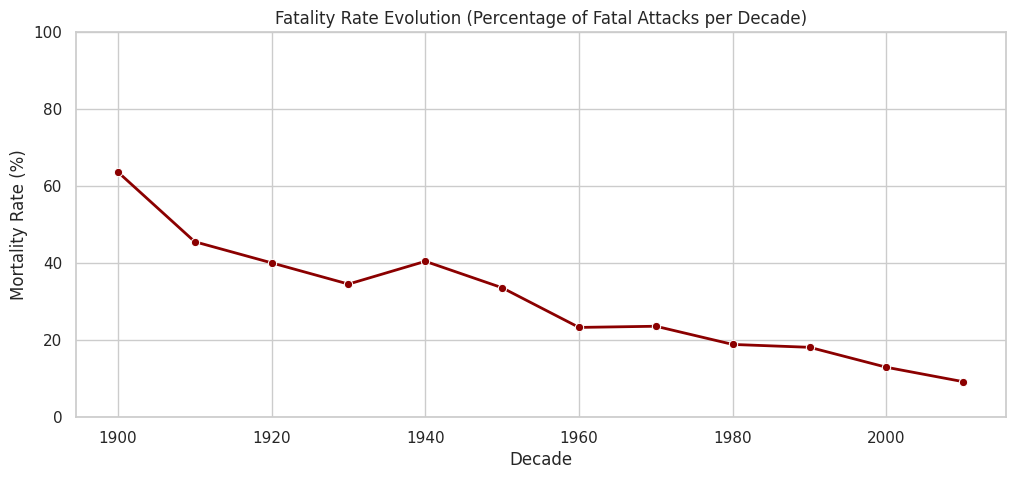

In [54]:
col_fatal = [col for col in data.columns if 'fatal' in col.lower()]

data['Is_Fatal'] = data[col_fatal[0]].astype(str).str.strip().str.upper()

data['Is_Fatal'] = data['Is_Fatal'].apply(lambda x: 'Y' if x == 'Y' else ('N' if x == 'N' else 'Unknown'))

data_20_cent = data[(data['Year'] > 1900) & (data['Year']<2023)].copy()
data_20_cent['Decade'] = (data_20_cent['Year'] // 10) * 10

fatality_dec = data_20_cent[data_20_cent['Is_Fatal'] != 'Unknown'].groupby('Decade')['Is_Fatal'].value_counts(normalize=True).unstack() * 100

plt.figure(figsize=(12, 5))
sns.lineplot(x=fatality_dec.index, y=fatality_dec['Y'], marker='o', color='darkred', linewidth=2)
plt.title('Fatality Rate Evolution (Percentage of Fatal Attacks per Decade)')
plt.xlabel('Decade')
plt.ylabel('Mortality Rate (%)')
plt.ylim(0, 100)
plt.show()